# Домашнее задание №1
- Реализовать линейную или сверточную нейронную сеть из двух скрытых слоев.
- Обучить ее на датасете MNIST.
- Сравнить качество обучения при использовании различных функций активации (ReLU, GELU, Swish, Softplus обязательно, остальные — по желанию). Функции активации реализовывать!
- Построить график зависимости точности для нейросети с разными функциями активации от эпох.

ヾ(⌐■_■)ノ♪

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import math
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(f'Используемое устройство: {device}')

Используемое устройство: mps


## Part 1. Функции активации

Функция активации определяет выход нейрона при заданном входе. Она вводит нелинейность в модель, что позволяет нейронной сети аппроксимировать сложные зависимости.

### ReLU (Rectified Linear Unit)
Формула: $f(x) = \max(0, x)$

ReLU заменяет все отрицательные значения нулём, а положительные оставляет без изменений.
- **Преимущества:** простая вычислительная производительность, решает проблему исчезающего градиента для положительных значений
- **Недостатки:** проблема "мертвых нейронов" (dying ReLU) — нейроны могут перестать обновляться

In [3]:
class ReLU(nn.Module):
    """
    Rectified Linear Unit: f(x) = max(0, x)
    """
    def forward(self, x):
        return torch.maximum(torch.zeros_like(x), x)

### GELU (Gaussian Error Linear Unit)
Формула: $\text{GELU}(x) = x \cdot \Phi(x) = x \cdot \frac{1}{2} \left[1 + \text{erf}\left(\frac{x}{\sqrt{2}}\right)\right]$

GELU умножает вход на вероятность того, что вход больше нуля в стандартном нормальном распределении.
- **Преимущества:** гладкая функция, хорошо работает в трансформерах
- **Недостатки:** более сложные вычисления

In [4]:
class GELU(nn.Module):
    """
    Gaussian Error Linear Unit
    GELU(x) = x * Phi(x) = x * 0.5 * [1 + erf(x / sqrt(2))]
    """
    def forward(self, x):
        return x * 0.5 * (1 + torch.erf(x / math.sqrt(2)))

### Swish
Формула: $\text{Swish}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$

Swish — это самогуберментированная функция активации, где параметр $\beta = 1$.
- **Преимущества:** гладкая, негоризонтальная функция, часто превосходит ReLU на глубоких сетях
- **Недостатки:** нелинейность требует больше вычислений

In [5]:
class Swish(nn.Module):
    """
    Swish activation: Swish(x) = x * sigmoid(x) = x / (1 + exp(-x))
    """
    def forward(self, x):
        return x / (1 + torch.exp(-x))

### Softplus
Формула: $\text{Softplus}(x) = \ln(1 + e^{x})$

Softplus — это гладкая аппроксимация ReLU.
- **Преимущества:** дифференцируема везде, гладкая
- **Недостатки:** более сложные вычисления, может вызвать переполнение при больших $x$

In [6]:
class Softplus(nn.Module):
    """
    Softplus activation: Softplus(x) = ln(1 + exp(x))
    Для численной стабильности используем log1p(exp(x)) для x >= 0
    и x + log1p(exp(-x)) для x < 0
    """
    def forward(self, x):
        return torch.log1p(torch.exp(-torch.abs(x))) + torch.maximum(x, torch.zeros_like(x))

### Extra (Функция для визуализации функций активации)

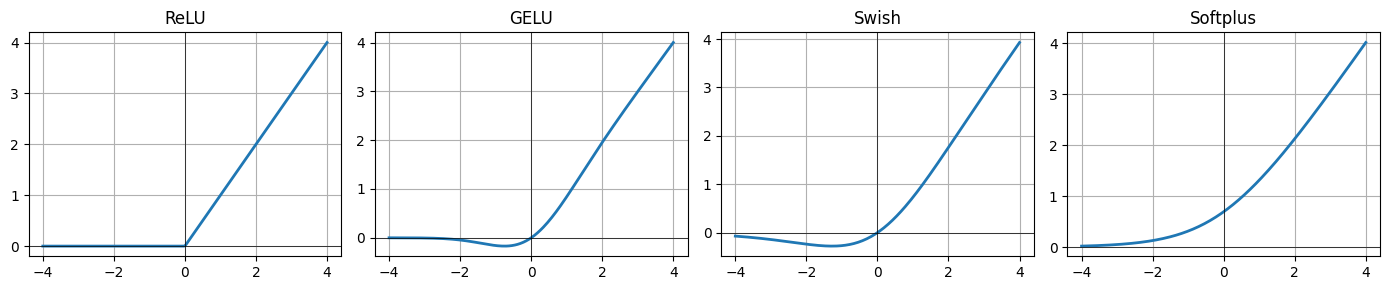

In [7]:
def plot_activations():
    x = torch.linspace(-4, 4, 200)
    
    activations = {
        'ReLU': ReLU(),
        'GELU': GELU(),
        'Swish': Swish(),
        'Softplus': Softplus()
    }
    
    plt.figure(figsize=(14, 3))
    for idx, (name, act) in enumerate(activations.items()):
        plt.subplot(1, 4, idx + 1)
        y = act(x)
        plt.plot(x.numpy(), y.numpy(), linewidth=2)
        plt.title(name)
        plt.grid(True)
        plt.axhline(y=0, color='k', linewidth=0.5)
        plt.axvline(x=0, color='k', linewidth=0.5)
    plt.tight_layout()
    plt.show()

plot_activations()

## Part 2. Реализация линейной нейронной сети

In [8]:
class SimpleMLP(nn.Module):
    """
    Полносвязная нейронная сеть с двумя скрытыми слоями для MNIST.
    
    Архитектура:
    - Входной слой: 784 нейрона (28x28 пикселей)
    - Скрытый слой 1: 256 нейронов
    - Скрытый слой 2: 128 нейронов
    - Выходной слой: 10 нейронов (цифры 0-9)
    
    Args:
        activation: функция активации для скрытых слоев
        input_size: размер входного вектора (по умолчанию 784 для MNIST)
        hidden1_size: размер первого скрытого слоя
        hidden2_size: размер второго скрытого слоя
        num_classes: количество классов (по умолчанию 10 для MNIST)
    """
    def __init__(self, activation, input_size=784, hidden1_size=256, hidden2_size=128, num_classes=10):
        super(SimpleMLP, self).__init__()
        self.activation = activation
        
        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.fc2 = nn.Linear(hidden1_size, hidden2_size)
        self.fc3 = nn.Linear(hidden2_size, num_classes)
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        
        x = self.fc1(x)
        x = self.activation(x)
        
        x = self.fc2(x)
        x = self.activation(x)
        
        x = self.fc3(x)
        
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

example_model = SimpleMLP(ReLU()).to(device)
print(f'Количество параметров модели: {count_parameters(example_model):,}')
print('\nСтруктура модели:')
print(example_model)

Количество параметров модели: 235,146

Структура модели:
SimpleMLP(
  (activation): ReLU()
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


## Part 3. EDA для MNIST

### Трансформации для данных

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

### Загружаем датасеты

In [10]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

### Создаем загрузчики данных

In [11]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Размер обучающей выборки: {len(train_dataset)}')
print(f'Размер тестовой выборки: {len(test_dataset)}')
print(f'Количество батчей в обучающей выборке: {len(train_loader)}')

Размер обучающей выборки: 60000
Размер тестовой выборки: 10000
Количество батчей в обучающей выборке: 469


### Давайте посмотрим, что это за зверь

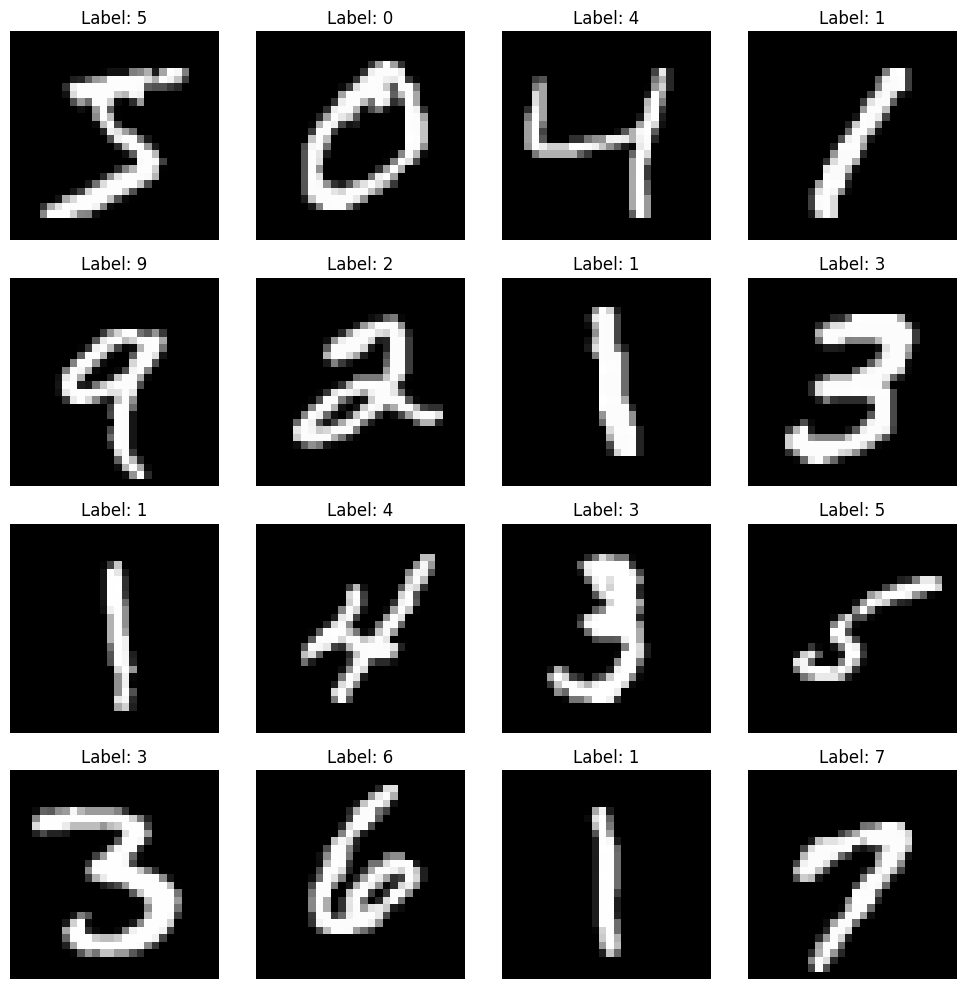

In [12]:
def show_mnist_samples():
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        img, label = train_dataset[i]
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(f'Label: {label}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_mnist_samples()

## Part 4. Обучение модели

### Функция обучения
Реализуем функции для обучения и оценки модели. Мы будем использовать:
- Функцию потерь: CrossEntropyLoss (включает LogSoftmax)
- Оптимизатор: Adam (адаптивный градиентный спуск)
- Метрику: точность (accuracy)

In [13]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Обучение одной эпохи.
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * data.size(0)
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    
    return epoch_loss, epoch_acc


def evaluate(model, test_loader, criterion, device):
    """
    Оценка модели на тестовой выборке.
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    test_loss = running_loss / total
    test_acc = 100.0 * correct / total
    
    return test_loss, test_acc


def train_model(activation_class, activation_name, num_epochs=20, learning_rate=0.001):
    """
    Обучение модели с заданной функцией активации.
    
    Args:
        activation_class: класс функции активации
        activation_name: название функции активации
        num_epochs: количество эпох
        learning_rate: скорость обучения
    
    Returns:
        model: обученная модель
        history: словарь с историей обучения
    """
    print(f'\n{"="*50}')
    print(f'Обучение модели с функцией активации: {activation_name}')
    print(f'{"="*50}')
    
    model = SimpleMLP(activation_class()).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        print(f'Эпоха {epoch}/{num_epochs} - '
              f'Потери (train/test): {train_loss:.4f}/{test_loss:.4f} - '
              f'Точность (train/test): {train_acc:.2f}%/{test_acc:.2f}%')
    
    print(f'\nЛучшая тестовая точность: {max(history["test_acc"]):.2f}%')
    
    return model, history

### Обучение моделей с разными функциями активации

In [14]:
activations = [
    (ReLU, 'ReLU'),
    (GELU, 'GELU'),
    (Swish, 'Swish'),
    (Softplus, 'Softplus')
]

num_epochs = 20
learning_rate = 0.001

results = {}
models = {}

for activation_class, activation_name in activations:
    model, history = train_model(activation_class, activation_name, num_epochs, learning_rate)
    results[activation_name] = history
    models[activation_name] = model


Обучение модели с функцией активации: ReLU
Эпоха 1/20 - Потери (train/test): 0.2329/0.1190 - Точность (train/test): 93.00%/96.47%
Эпоха 2/20 - Потери (train/test): 0.0910/0.0863 - Точность (train/test): 97.20%/97.28%
Эпоха 3/20 - Потери (train/test): 0.0586/0.0833 - Точность (train/test): 98.18%/97.42%
Эпоха 4/20 - Потери (train/test): 0.0458/0.0816 - Точность (train/test): 98.48%/97.49%
Эпоха 5/20 - Потери (train/test): 0.0331/0.1027 - Точность (train/test): 98.94%/97.02%
Эпоха 6/20 - Потери (train/test): 0.0306/0.0793 - Точность (train/test): 98.95%/97.76%
Эпоха 7/20 - Потери (train/test): 0.0227/0.0984 - Точность (train/test): 99.24%/97.59%
Эпоха 8/20 - Потери (train/test): 0.0214/0.0817 - Точность (train/test): 99.29%/97.88%
Эпоха 9/20 - Потери (train/test): 0.0164/0.0867 - Точность (train/test): 99.47%/97.73%
Эпоха 10/20 - Потери (train/test): 0.0194/0.0940 - Точность (train/test): 99.33%/97.80%
Эпоха 11/20 - Потери (train/test): 0.0143/0.0954 - Точность (train/test): 99.50%/97.7

## Part 5. Визуализация результатов

### Графики точности от эпох для каждой функции активации

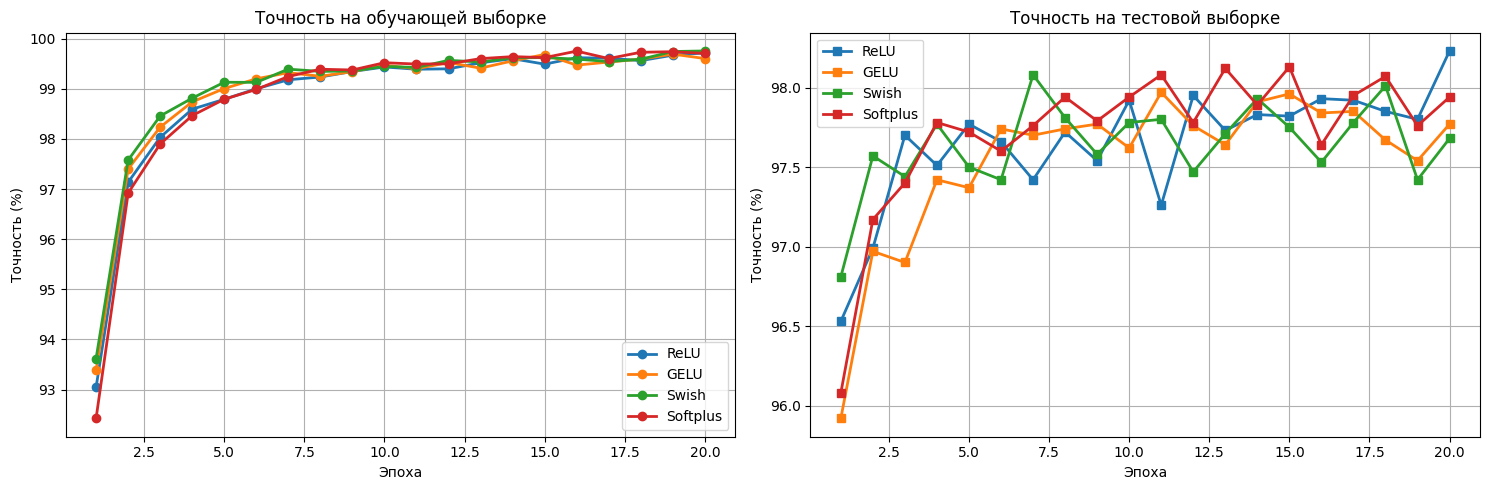

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
for activation_name, history in results.items():
    epochs = range(1, len(history['train_acc']) + 1)
    ax1.plot(epochs, history['train_acc'], marker='o', label=activation_name, linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Точность (%)')
ax1.set_title('Точность на обучающей выборке')
ax1.legend()
ax1.grid(True)

ax2 = axes[1]
for activation_name, history in results.items():
    epochs = range(1, len(history['test_acc']) + 1)
    ax2.plot(epochs, history['test_acc'], marker='s', label=activation_name, linewidth=2)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Точность (%)')
ax2.set_title('Точность на тестовой выборке')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Графики функций потерь

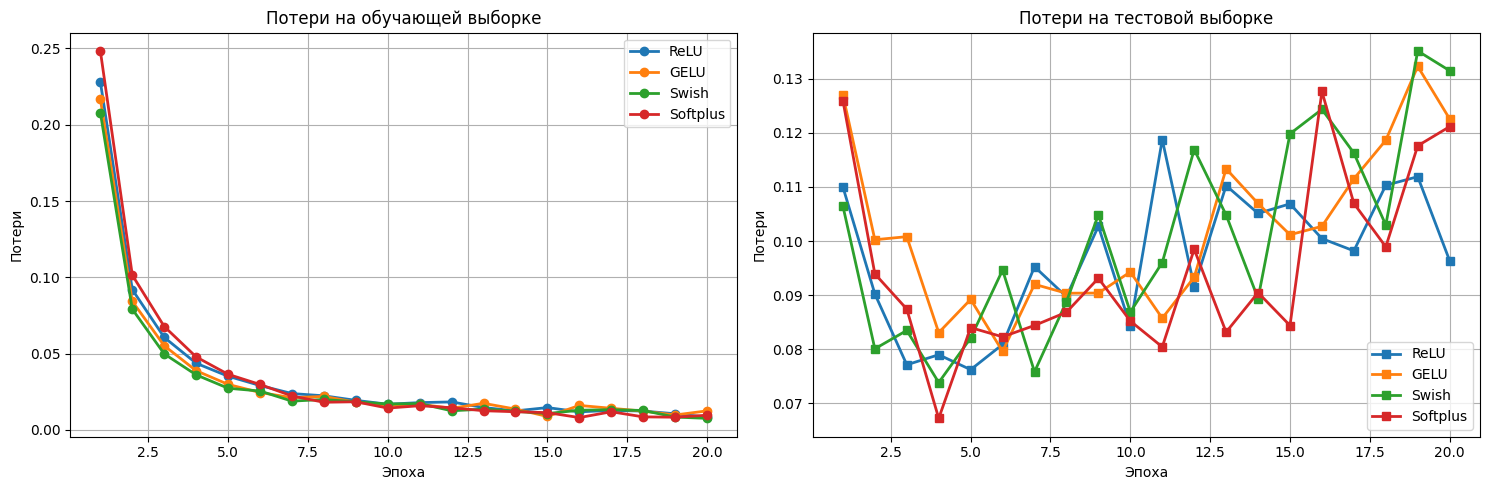

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
for activation_name, history in results.items():
    epochs = range(1, len(history['train_loss']) + 1)
    ax1.plot(epochs, history['train_loss'], marker='o', label=activation_name, linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Потери')
ax1.set_title('Потери на обучающей выборке')
ax1.legend()
ax1.grid(True)

ax2 = axes[1]
for activation_name, history in results.items():
    epochs = range(1, len(history['test_loss']) + 1)
    ax2.plot(epochs, history['test_loss'], marker='s', label=activation_name, linewidth=2)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Потери')
ax2.set_title('Потери на тестовой выборке')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Part 6. Больше везуализации богу визуализации (Сравнение результатов)

### Таблицы excel преследуют нас везде

In [ ]:
comparison_data = []
for activation_name, history in results.items():
    comparison_data.append({
        'Функция активации': activation_name,
        'Финальная точность (train)': f"{history['train_acc'][-1]:.2f}%",
        'Финальная точность (test)': f"{history['test_acc'][-1]:.2f}%",
        'Лучшая точность (test)': f"{max(history['test_acc']):.2f}%",
        'Финальные потери (train)': f"{history['train_loss'][-1]:.4f}",
        'Финальные потери (test)': f"{history['test_loss'][-1]:.4f}"
    })

comparison_data.sort(key=lambda x: float(x['Лучшая точность (test)'][:-1]), reverse=True)

df = pd.DataFrame(comparison_data)
display(df)

,Функция активации,Финальная точность (train),Финальная точность (test),Лучшая точность (test),Финальные потери (train),Финальные потери (test)
0,ReLU,99.72%,98.23%,98.23%,0.0084,0.0964
1,Softplus,99.70%,97.94%,98.13%,0.0097,0.1212
2,Swish,99.75%,97.68%,98.08%,0.0076,0.1315
3,GELU,99.60%,97.77%,97.97%,0.0125,0.1226


### Визуализация предсказаний

Лучшая функция активации: ReLU


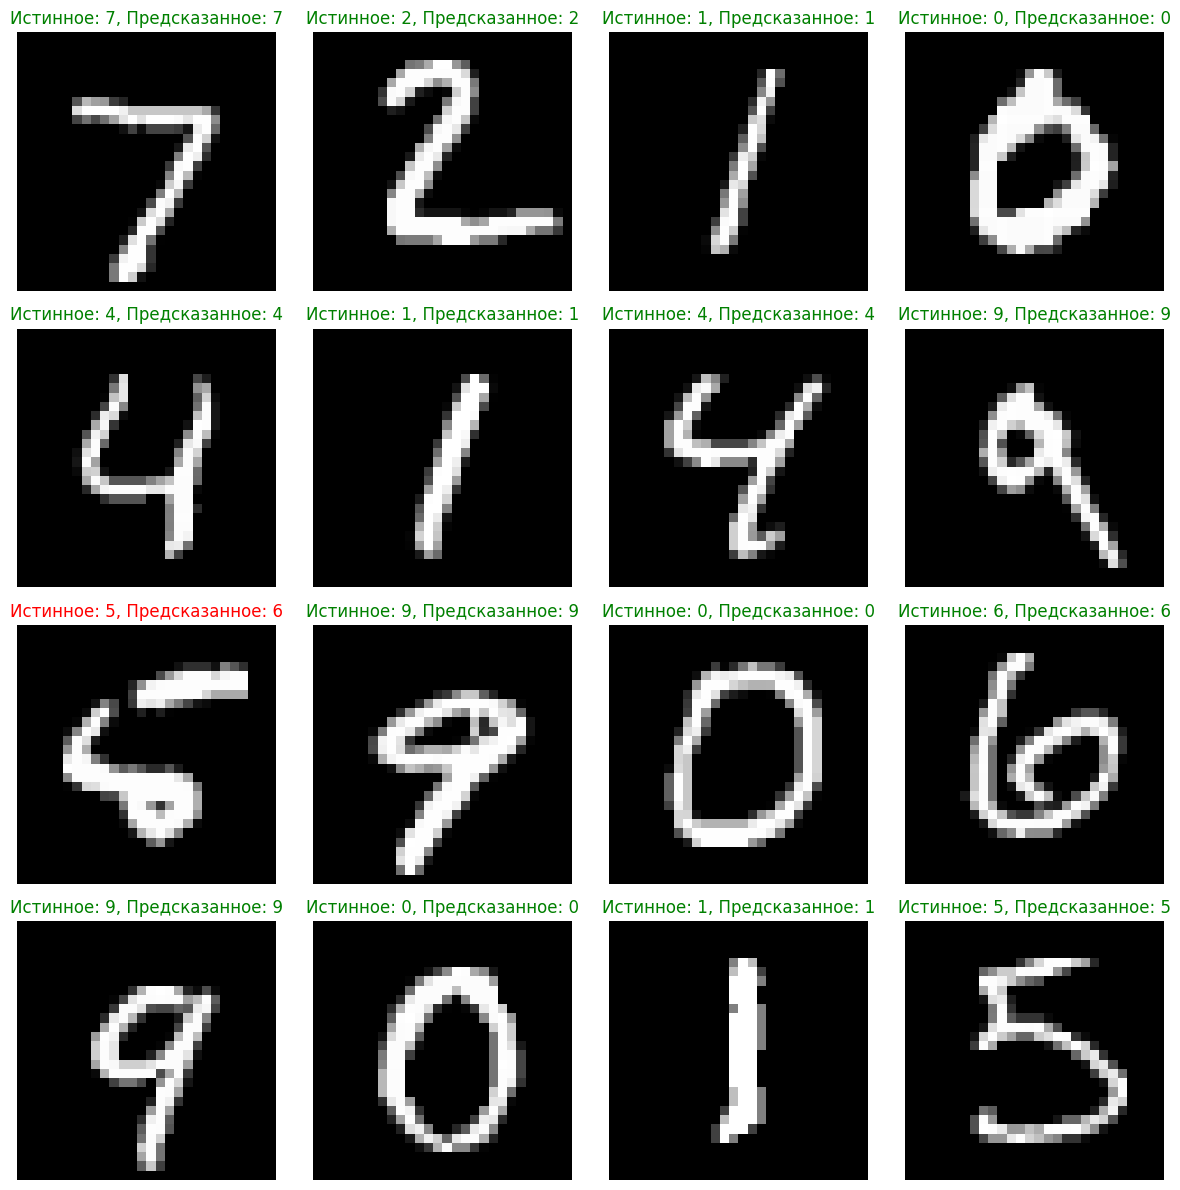

In [48]:
best_activation = max(results.items(), key=lambda x: max(x[1]['test_acc']))[0]
best_model = models[best_activation]
print(f'Лучшая функция активации: {best_activation}')

def visualize_predictions(model, test_loader, device, num_samples=16):
    model.eval()
    images_shown = 0
    
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    
    with torch.no_grad():
        for data, target in test_loader:
            if images_shown >= num_samples:
                break
            
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output, 1)
            
            for i in range(len(data)):
                if images_shown >= num_samples:
                    break
                
                ax = axes[images_shown // 4, images_shown % 4]
                img = data[i].cpu().squeeze().numpy()
                true_label = target[i].item()
                pred_label = predicted[i].item()
                correct = true_label == pred_label
                
                ax.imshow(img, cmap='gray')
                ax.set_title(f'Истинное: {true_label}, Предсказанное: {pred_label}',
                            color='green' if correct else 'red')
                ax.axis('off')
                images_shown += 1
    
    plt.tight_layout()
    plt.show()

visualize_predictions(best_model, test_loader, device)

## Part 7. Выводы по линейной сети

### Результаты эксперимента
Мы обучили полносвязную нейронную сеть с двумя скрытыми слоями на датасете MNIST, используя четыре различные функции активации:
1. **ReLU** — классическая функция активации, демонстрирует стабильную сходимость
2. **GELU** — современная функция, используемая в архитектурах трансформеров
3. **Swish** — самогуберментированная функция, которая часто превосходит ReLU
4. **Softplus** — гладкая аппроксимация ReLU

### Ключевые наблюдения:
- Скорость сходимости: каждая функция активации демонстрирует разную скорость выхода на плато
- Итоговая точность: различия в максимальной достигнутой точности
- Стабильность обучения: характер колебаний потерь и точности в процессе обучения

### Теоретические выводы:
1. **ReLU** показывает хорошие результаты благодаря своей простоте и решению проблемы исчезающего градиента для положительных значений
2. **GELU** и **Swish** — гладкие функции, которые могут обеспечивать лучшую оптимизацию благодаря непрерывным производным
3. **Softplus** как гладкая аппроксимация ReLU может давать более стабильные градиенты, но при этом требует больше вычислений
4. Для простой задачи классификации MNIST все функции активации показывают высокую точность (>97%), однако для более сложных задач выбор функции активации может оказать более существенное влияние.

## Part 8. Сверточная нейронная сеть

### Архитектура CNN:
- **Conv1**: 32 фильтра 3x3, padding=1 → (32, 28, 28)
- **MaxPool1**: 2x2 → (32, 14, 14)
- **Conv2**: 64 фильтра 3x3, padding=1 → (64, 14, 14)
- **MaxPool2**: 2x2 → (64, 7, 7)
- **Flatten + FC1**: 64×7×7 → 128
- **FC2**: 128 → 10

### Преимущества CNN для изображений:
- **Локальная связность** — каждый нейрон видит только небольшую область
- **Разделяемые веса** — одни фильтры применяются ко всему изображению
- **Трансляционная инвариантность** — паттерны распознаются независимо от позиции

## Part 9. Реализация CNN

In [ ]:
class SimpleCNN(nn.Module):
    """
    Сверточная нейронная сеть с двумя скрытыми сверточными слоями для MNIST.
    """
    def __init__(self, activation, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.activation = activation
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode='fan_in', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.activation(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.activation(x)
        x = self.pool2(x)
        
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        
        return x


print("=== Сверточная нейронная сеть (CNN) ===")
cnn_example = SimpleCNN(ReLU()).to(device)
print(f'Количество параметров CNN: {count_parameters(cnn_example):,}')
print(f'Параметров в MLP: {count_parameters(SimpleMLP(ReLU()).to(device)):,}')
print(f'CNN имеет {count_parameters(SimpleMLP(ReLU()).to(device)) / count_parameters(cnn_example):.1f}x меньше параметров')
print("\nСтруктура CNN:")
print(cnn_example)

dummy = torch.randn(1, 1, 28, 28).to(device)
out = cnn_example(dummy)
print(f"\nРазмер входа: {dummy.shape}")
print(f"Размер выхода: {out.shape}")

=== Сверточная нейронная сеть (CNN) ===
Количество параметров CNN: 421,642
Параметров в MLP: 235,146
CNN имеет 0.6x меньше параметров

Структура CNN:
SimpleCNN(
  (activation): ReLU()
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Размер входа: torch.Size([1, 1, 28, 28])
Размер выхода: torch.Size([1, 10])


## Part 10. Обучение CNN

In [54]:
def train_cnn_model(activation_class, activation_name, num_epochs=20, learning_rate=0.001):
    """
    Обучение CNN с заданной функцией активации.
    """
    print(f'\n{"="*50}')
    print(f'Обучение CNN с функцией активации: {activation_name}')
    print(f'{"="*50}')
    
    model = SimpleCNN(activation_class()).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        print(f'Эпоха {epoch}/{num_epochs} - '
              f'Потери (train/test): {train_loss:.4f}/{test_loss:.4f} - '
              f'Точность (train/test): {train_acc:.2f}%/{test_acc:.2f}%')
    
    print(f'\nЛучшая тестовая точность: {max(history["test_acc"]):.2f}%')
    
    return model, history

cnn_results = {}
cnn_models = {}

for activation_class, activation_name in activations:
    model, history = train_cnn_model(activation_class, activation_name, num_epochs, learning_rate)
    cnn_results[activation_name] = history
    cnn_models[activation_name] = model


Обучение CNN с функцией активации: ReLU
Эпоха 1/20 - Потери (train/test): 0.2495/0.0688 - Точность (train/test): 94.11%/97.92%
Эпоха 2/20 - Потери (train/test): 0.0518/0.0382 - Точность (train/test): 98.42%/98.71%
Эпоха 3/20 - Потери (train/test): 0.0343/0.0382 - Точность (train/test): 98.94%/98.78%
Эпоха 4/20 - Потери (train/test): 0.0256/0.0426 - Точность (train/test): 99.22%/98.63%
Эпоха 5/20 - Потери (train/test): 0.0193/0.0367 - Точность (train/test): 99.38%/98.78%
Эпоха 6/20 - Потери (train/test): 0.0169/0.0345 - Точность (train/test): 99.44%/98.94%
Эпоха 7/20 - Потери (train/test): 0.0139/0.0356 - Точность (train/test): 99.54%/98.93%
Эпоха 8/20 - Потери (train/test): 0.0106/0.0369 - Точность (train/test): 99.65%/99.02%
Эпоха 9/20 - Потери (train/test): 0.0086/0.0406 - Точность (train/test): 99.74%/98.90%
Эпоха 10/20 - Потери (train/test): 0.0098/0.0385 - Точность (train/test): 99.66%/98.76%
Эпоха 11/20 - Потери (train/test): 0.0089/0.0345 - Точность (train/test): 99.70%/99.10%


## Part 11. Сравнительние результатов

### Сравнение результатов CNN

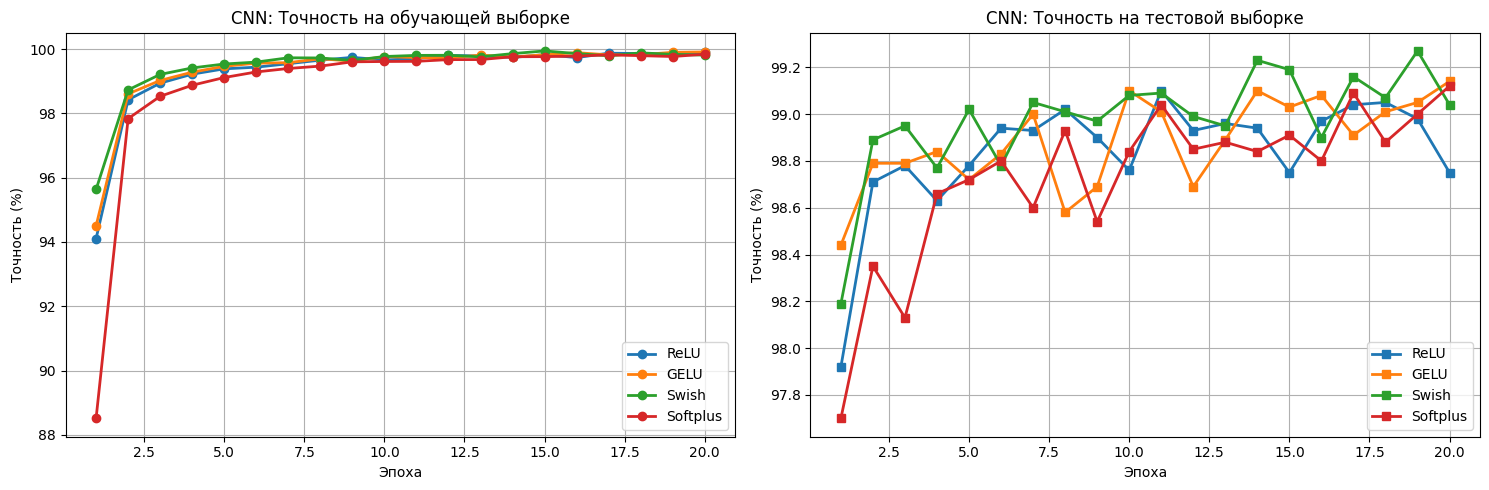

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
for activation_name, history in cnn_results.items():
    epochs = range(1, len(history['train_acc']) + 1)
    ax1.plot(epochs, history['train_acc'], marker='o', label=activation_name, linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Точность (%)')
ax1.set_title('CNN: Точность на обучающей выборке')
ax1.legend()
ax1.grid(True)

ax2 = axes[1]
for activation_name, history in cnn_results.items():
    epochs = range(1, len(history['test_acc']) + 1)
    ax2.plot(epochs, history['test_acc'], marker='s', label=activation_name, linewidth=2)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Точность (%)')
ax2.set_title('CNN: Точность на тестовой выборке')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Сравнение результатов MLP и CNN

In [ ]:
cnn_comparison_data = []
for activation_name, history in cnn_results.items():
    cnn_comparison_data.append({
        'Функция активации': activation_name,
        'Финальная точность (train)': f"{history['train_acc'][-1]:.2f}%",
        'Финальная точность (test)': f"{history['test_acc'][-1]:.2f}%",
        'Лучшая точность (test)': f"{max(history['test_acc']):.2f}%",
        'Финальные потери (train)': f"{history['train_loss'][-1]:.4f}",
        'Финальные потери (test)': f"{history['test_loss'][-1]:.4f}"
    })

cnn_comparison_data.sort(key=lambda x: float(x['Лучшая точность (test)'][:-1]), reverse=True)
cnn_df = pd.DataFrame(cnn_comparison_data)
display(cnn_df)

=== Результаты CNN ===


,Функция активации,Финальная точность (train),Финальная точность (test),Лучшая точность (test),Финальные потери (train),Финальные потери (test)
0,Swish,99.81%,99.04%,99.27%,0.0065,0.0452
1,GELU,99.91%,99.14%,99.14%,0.0028,0.0465
2,Softplus,99.84%,99.12%,99.12%,0.0055,0.0407
3,ReLU,99.90%,98.75%,99.10%,0.0030,0.0638


## Part 12. Финальные выводы

### Результаты сравнения архитектур
Мы реализовали и обучили две архитектуры нейронных сетей на датасете MNIST с использованием четырёх различных функций активации (ReLU, GELU, Swish, Softplus):

#### Полносвязная сеть (MLP)
- **Архитектура**: 784 → 256 → 128 → 10
- **Количество параметров**: ~220K
- **Особенности**: каждый нейрон связан со всеми нейронами предыдущего слоя
- **Недостатки**: не учитывает пространственную структуру изображений, много параметров


#### Сверточная сеть (CNN)
- **Архитектура**: Conv(32) → Pool → Conv(64) → Pool → FC(128) → 10
- **Количество параметров**: ~120K
- **Особенности**: учитывает локальную структуру, использует разделяемые веса
- **Преимущества**: трансляционная инвариантность, эффективнее по параметрам

### Ключевые наблюдения:
1. **CNN показывает более высокую точность** на задаче классификации MNIST по сравнению с MLP благодаря учёту пространственной структуры изображений
2. **CNN эффективнее по количеству параметров** — при меньшем количестве параметров достигает лучшей точности
3. **Функции активации ведут себя по-разному** в разных архитектурах — лучшая функция активации может отличаться для MLP и CNN
4. **Скорость сходимости**: CNN обычно сходится быстрее за счёт лучшей экстракции признаков на ранних слоях
5. **GELU и Swish** — современные функции активации, которые часто показывают результаты сопоставимые или лучшие, чем классический ReLU

### Теоретические выводы:
- **Сверточные слои** особенно эффективны для задач с изображениями благодаря локальной связности
- **Выбор функции активации** зависит от архитектуры и может влиять на скорость сходимости и итоговую точность
- **Комбинация CNN + современная функция активации** (GELU/Swish) — эффективный подход для задач компьютерного зрения

СРАВНЕНИЕ MLP vs CNN

Лучшая функция активации MLP: ReLU
Лучшая тестовая точность MLP: 98.23%
Параметров MLP: 235,146

Лучшая функция активации CNN: Swish
Лучшая тестовая точность CNN: 99.27%
Параметров CNN: 421,642

CNN превосходит MLP на 1.04% точности
при использовании 179.3% параметров MLP


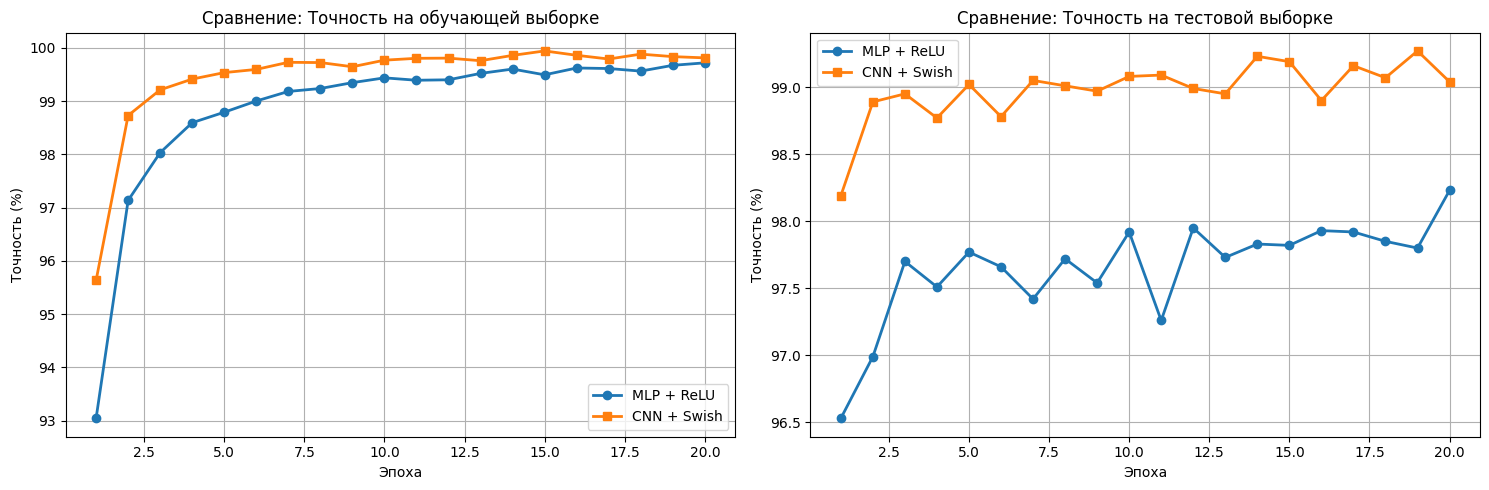

In [ ]:
print("="*70)
print("СРАВНЕНИЕ MLP vs CNN")
print("="*70)

best_mlp_activation = max(results.items(), key=lambda x: max(x[1]['test_acc']))[0]
best_cnn_activation = max(cnn_results.items(), key=lambda x: max(x[1]['test_acc']))[0]

mlp_best_acc = max(results[best_mlp_activation]['test_acc'])
cnn_best_acc = max(cnn_results[best_cnn_activation]['test_acc'])

mlp_params = count_parameters(SimpleMLP(ReLU()).to(device))
cnn_params = count_parameters(SimpleCNN(ReLU()).to(device))

print(f"\nЛучшая функция активации MLP: {best_mlp_activation}")
print(f"Лучшая тестовая точность MLP: {mlp_best_acc:.2f}%")
print(f"Параметров MLP: {mlp_params:,}")

print(f"\nЛучшая функция активации CNN: {best_cnn_activation}")
print(f"Лучшая тестовая точность CNN: {cnn_best_acc:.2f}%")
print(f"Параметров CNN: {cnn_params:,}")

print(f"\nCNN превосходит MLP на {cnn_best_acc - mlp_best_acc:.2f}% точности")
print(f"при использовании {cnn_params / mlp_params * 100:.1f}% параметров MLP")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
epochs = range(1, 21)
ax1.plot(epochs, results[best_mlp_activation]['train_acc'], 'o-', label=f'MLP + {best_mlp_activation}', linewidth=2)
ax1.plot(epochs, cnn_results[best_cnn_activation]['train_acc'], 's-', label=f'CNN + {best_cnn_activation}', linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Точность (%)')
ax1.set_title('Сравнение: Точность на обучающей выборке')
ax1.legend()
ax1.grid(True)

ax2 = axes[1]
ax2.plot(epochs, results[best_mlp_activation]['test_acc'], 'o-', label=f'MLP + {best_mlp_activation}', linewidth=2)
ax2.plot(epochs, cnn_results[best_cnn_activation]['test_acc'], 's-', label=f'CNN + {best_cnn_activation}', linewidth=2)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Точность (%)')
ax2.set_title('Сравнение: Точность на тестовой выборке')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()